* check the thermalization and autocorrelations for the given parameters

* using the n_therm and the n_meas, look at the outputs of the nested sampling of CPN

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

import glob

In [2]:
L, T = 72, 72
V = L*T

N = 21
beta = 0.6

n_cool_step = 50     # number of cooling steps 
meas_cool_every = 5
skip_topo = n_cool_step // meas_cool_every + 1

# action prefactor 
pf = 2#beta #*N*V

In [3]:
n_live = 500
n_iter = 4
n_live_eff = n_iter * n_live
#n_meas = 10000    # get this later from the len of the array!

In [4]:
dir_list = sorted(glob.glob("out_data/res*"))
gen_df  = "dati.dat"
topo_df = "topo.dat"

dir_list

['out_data/res_0',
 'out_data/res_1',
 'out_data/res_2',
 'out_data/res_3',
 'out_data/res_4',
 'out_data/res_5',
 'out_data/res_6',
 'out_data/res_7']

In [5]:
""" 
the cols in the files are: 
gen_data:
    [0]: Conf. update index
    [1]: energy density S/(2NVb)
    [2]: magn_susc G(p=0)
    [3]: magn_susc G(p=q) => get corr length ~ G(q)/G(0)

topo_data:
    [0]: Conf. update index
    [1]: cooling step
    [2]: geom. top.charge Q_U
    [3]: geom. magn_susc_U
    [4]: geom. top.charge Q_z
    [5]: geom. magn_susc_z
    [6]: non-geom topo charge ~ plaquette
    [7]: non-geom topo susc ~ plaquette
"""

' \nthe cols in the files are: \ngen_data:\n    [0]: Conf. update index\n    [1]: energy density S/(2NVb)\n    [2]: magn_susc G(p=0)\n    [3]: magn_susc G(p=q) => get corr length ~ G(q)/G(0)\n\ntopo_data:\n    [0]: Conf. update index\n    [1]: cooling step\n    [2]: geom. top.charge Q_U\n    [3]: geom. magn_susc_U\n    [4]: geom. top.charge Q_z\n    [5]: geom. magn_susc_z\n    [6]: non-geom topo charge ~ plaquette\n    [7]: non-geom topo susc ~ plaquette\n'

# Load data into combined list

In [6]:
gen_data = []
topo_data = []

cutoff = -1 #8000

for d in dir_list[4:]:
   gen_data.append(np.loadtxt(os.path.join(d,gen_df))[:cutoff])
   topo_data.append(np.loadtxt(os.path.join(d,topo_df))[:cutoff*skip_topo]) 

In [7]:
gen_data  = np.concatenate(gen_data, axis=0)
topo_data = np.concatenate(topo_data, axis=0)

print(gen_data.shape, "\n", topo_data.shape)

(31982, 4) 
 (351802, 8)


In [8]:
print(topo_data[::skip_topo].shape)

(31982, 8)


In [9]:
order = np.argsort(gen_data[:,1])[::-1]   # sort after the action vals, from largest to smallest

print(gen_data[:,1][order][:10])

[0.86754474 0.86675751 0.86673872 0.86659598 0.86619725 0.86603306
 0.86591996 0.86563763 0.86554099 0.86541608]


In [10]:
## for gen_data~[N, m], topo_data~[N*skip_topo, k]:
gen_sorted = gen_data[order]

# reshape topo_data into (N, skip_topo, k)
topo_blocks = topo_data.reshape(len(gen_data), skip_topo, -1)

# reorder the blocks
topo_sorted = topo_blocks[order]

# if needed, flatten back to the original shape
topo_sorted = topo_sorted.reshape(-1, topo_data.shape[1])

print(gen_sorted.shape, "\n", topo_sorted.shape)

(31982, 4) 
 (351802, 8)


are we a little skewed because we did not stop?


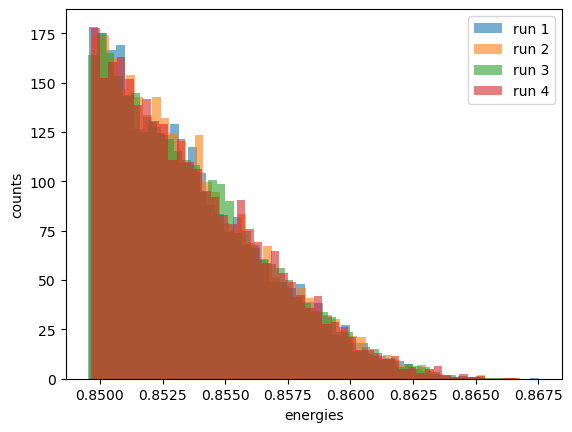

In [11]:
# look at different-run energies:
run_nr = 1
for d in dir_list[4:]:
   s = np.loadtxt(os.path.join(d,gen_df))[:,1]
   #s = s[:int(1*len(s)//2)]
   _=plt.hist(s, bins=50, alpha=0.6, label=f"run {run_nr}", density=True)
   run_nr += 1

plt.legend()
plt.xlabel("energies")
plt.ylabel("counts")

print("are we a little skewed because we did not stop?")

# look at data

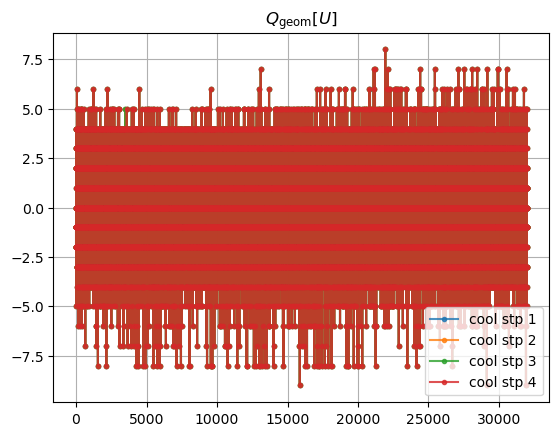

(-5.0, 5.0)

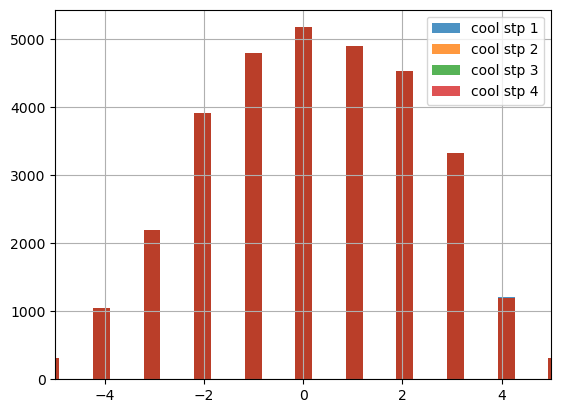

In [12]:
cool_stp = 1    # translates to meas_every_cool... * cool_stp cooling steps
for cool_stp in range(1, 5):
    plt.plot(topo_sorted[cool_stp::skip_topo,2][:], alpha=0.8, marker="o", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{geom}[U]$")
plt.show()

for cool_stp in range(1,5):
    plt.hist(topo_sorted[cool_stp::skip_topo,2][:], alpha=0.8, bins=50, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.xlim(-5,5)

Text(0.5, 0, 'sample nr.')

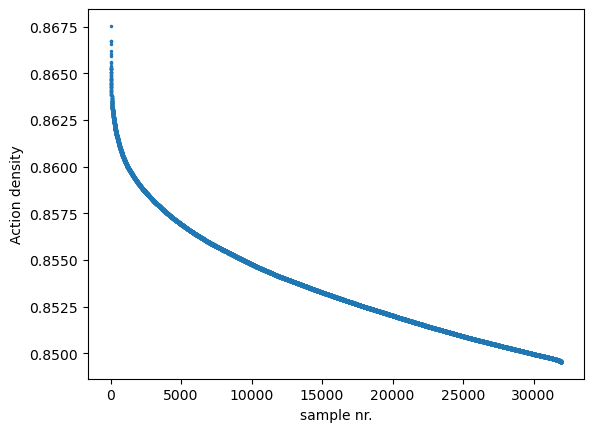

In [14]:
# progression of the action values?
plt.plot(gen_sorted[::,1], marker=".", linestyle="", ms=3)

#plt.xlim(0, 100)

plt.ylabel("Action density")
plt.xlabel("sample nr.")

In [14]:
def get_acf(A):
    A_mean = np.mean(A)
    diff_A = A-A_mean
    std_A = np.std(A)

    diff_A /= std_A

    T = len(diff_A)
    corr_fun = np.zeros((T))

    for t in range(T):
        for t0 in range(T-t):
            corr_fun[t] += diff_A[t0]*diff_A[t0+t]
        corr_fun[t] /= (T-t)
    
    return corr_fun       

def autocorrelation(x, normalize=True):
    """
    Compute the autocorrelation function of a 1D array.

    Parameters
    ----------
    x : array_like
        Input signal.
    normalize : bool, optional
        If True, normalize so that acf[0] = 1.

    Returns
    -------
    acf : ndarray
        Autocorrelation for lags 0, 1, ..., N-1.
    """
    x = np.asarray(x)
    x = x - np.mean(x)

    acf = np.correlate(x, x, mode='full')
    acf = acf[len(x)-1:]  # keep non-negative lags

    if normalize:
        acf = acf / acf[0]

    return acf

def integrated_autocorrelation_time(x, max_lag=None):
    acf = autocorrelation(x)

    if max_lag is None:
        max_lag = len(acf) - 1

    return 0.5 + np.sum(acf[1:max_lag+1])

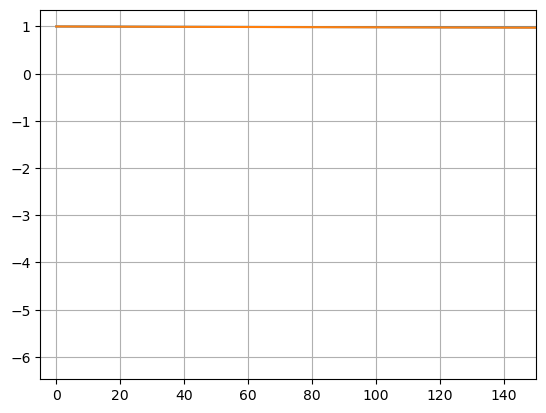

KeyboardInterrupt: 

In [15]:
skip = 1

plt.plot(get_acf(gen_sorted[::skip,1]))
plt.plot(autocorrelation(gen_sorted[::skip,1]))
plt.grid()
plt.xlim(-5, 150/skip)
plt.show()

w = np.arange(2,int(200/skip))
tau_int = np.empty_like(w)
for w0 in w:
    tau_int[w0-w[0]] = integrated_autocorrelation_time(gen_sorted[::skip,1], max_lag=w0)

plt.plot(tau_int)

lets say 10 is 2xtau_int here... does it even make sense to consider the autocorrelation here?

# look at nested sampling Z

In [15]:
gen_data  = gen_sorted
topo_data = topo_sorted

energies = 2*gen_data[:,1]

print(gen_data.shape, "\n", topo_data.shape)

(31982, 4) 
 (351802, 8)


In [16]:
n_meas = len(gen_data)
print(n_meas)

31982


In [17]:
# similar to Simone Romiti's lattice tools: https://github.com/simone-romiti/lattice_data_tools/tree/main

# get set of Beta-distributed vals X_i
# rng = np.random.default_rng()
#t_list = rng.beta(n_live, 1, size=(n_meas,))
# x_list = np.cumprod(t_list)

## simple approach:
log_t = (-1.0/n_live_eff) * np.ones(n_meas)
t_list = np.exp(log_t)

# get log(x)
log_x = np.cumsum(log_t)
x_list = np.exp(log_x)
h_list = np.exp(log_x[:-1]) - np.exp(log_x[1:])
#print(log_x.shape)

# get log(w) (fwd definition ~ w_i = x_i-1 - x_i)
log_w = log_x  + np.log(1.0 - t_list)

In [18]:
# get log(w)
"""log_w0 = 0
log_w = [np.log(1-t_list[0])]
for i in range(1, len(t_list-1)):
    log_w0 += np.log(t_list[i-1])
    log_w.append(log_w0-np.log(1-t_list[i]))

log_w = np.array(log_w)"""

'log_w0 = 0\nlog_w = [np.log(1-t_list[0])]\nfor i in range(1, len(t_list-1)):\n    log_w0 += np.log(t_list[i-1])\n    log_w.append(log_w0-np.log(1-t_list[i]))\n\nlog_w = np.array(log_w)'

In [19]:
from scipy.special import logsumexp

In [20]:
# get normalized weights: (L=1 here since it is part of the prior!)
log_Z_unnorm = logsumexp(log_w)
log_w_norm = log_w - log_Z_unnorm

In [21]:
# from Simones tools:
def get_log_Z_curve(log_wL_normalized: np.ndarray):
    """
    The partition function is normalized to 1.
    The total weights w_i*L_i are the discrete version of the probability density function.
    The cumulative sum of the total weights gives use the cumulative density function. This function returns the log of that curve.
    """
    n_iter = log_wL_normalized.shape[0]
    s = log_wL_normalized[0]
    logZ = [s]
    for i in range(n_iter-1):
        s = np.logaddexp(s, log_wL_normalized[i+1])
        logZ.append(s)
    #---
    res = np.array(logZ)
    return res

Text(0, 0.5, 'Z')

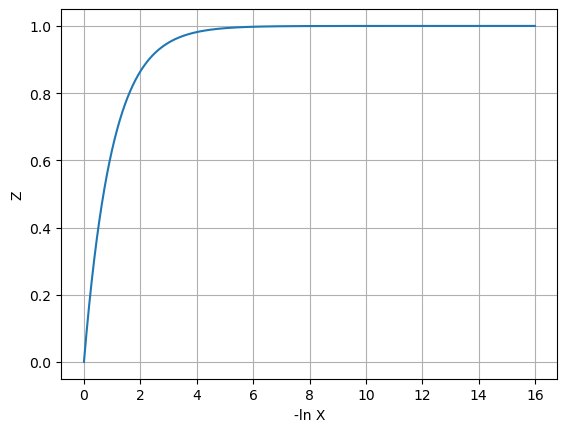

In [22]:
log_Z_curve = get_log_Z_curve(log_w_norm)
plt.plot(-log_x,np.exp(log_Z_curve))

plt.grid()
plt.xlabel("-ln X")
plt.ylabel("Z")

In [23]:
# does it do the same as the function above? yes!
log_Z = []
for i in range(len(energies)):
    log_Z.append(logsumexp(log_w[:i]))  #-energies[:i]+
log_Z = np.array(log_Z)
log_Z_norm = log_Z[-1]
log_Z -= log_Z_norm
log_Z.shape
# log_Z_tot = logsumexp(-energies+log_w)

(31982,)

Text(0, 0.5, 'Z')

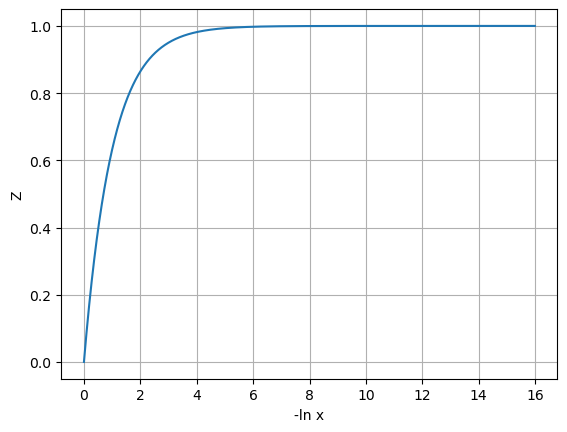

In [24]:
plt.plot(-np.log(x_list[:]), np.exp(log_Z))       #
plt.grid()
plt.xlabel("-ln x")
plt.ylabel("Z")

In [25]:
log_Z = []
for i in range(len(energies)):
    log_Z.append(logsumexp(log_w_norm[:i]))  #-energies[:i]+
log_Z = np.array(log_Z)
log_Z.shape
# log_Z_tot = logsumexp(-energies+log_w)

(31982,)

Text(0, 0.5, 'Z')

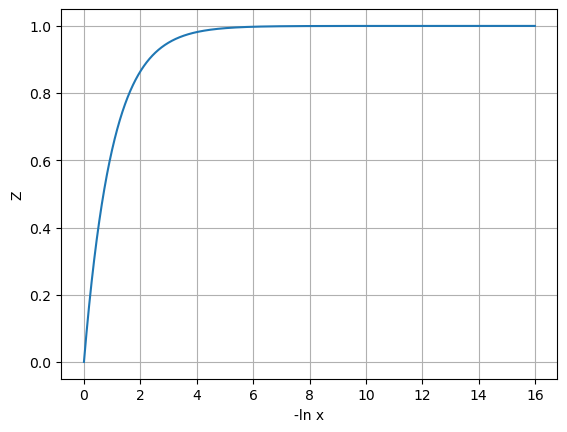

In [26]:
plt.plot(-np.log(x_list[:]), np.exp(log_Z))       #
plt.grid()
plt.xlabel("-ln x")
plt.ylabel("Z")

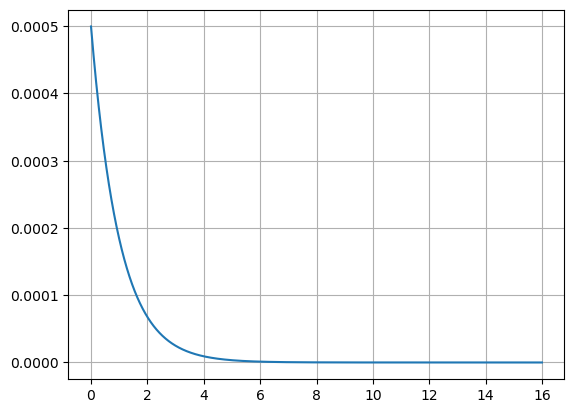

In [27]:
plt.plot(-np.log(x_list[1:]), h_list)       #np.exp(Z_can)*
plt.grid()

# look at the energy
$$ 
    \langle O \rangle = \frac{1}{Z}\sum_i L_i^{\Delta\beta} w_i O_i
$$

Text(0, 0.5, 'counts')

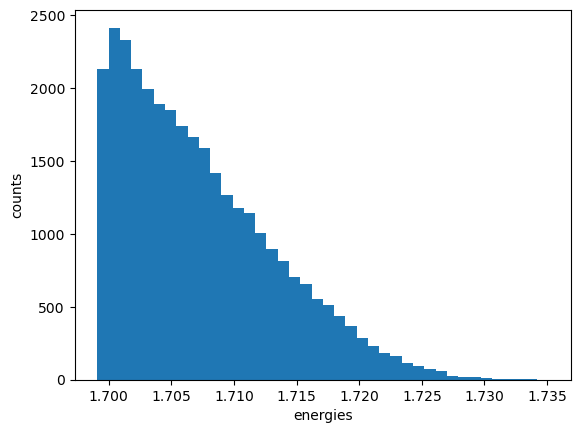

In [28]:
energies = 2*gen_data[:,1]
_=plt.hist(energies, bins=40)
plt.xlabel("energies")
plt.ylabel("counts")

In [29]:
avg_obs = np.sum(np.exp(log_w_norm)*energies)
print(avg_obs)

print("Thesis result for b=0.6, L=72, N=21:\t1.716722(2)")

1.719673149003897
Thesis result for b=0.6, L=72, N=21:	1.716722(2)


# Look at the geometric cooled charge

Can we also get the correct $\langle Q^2 \rangle?

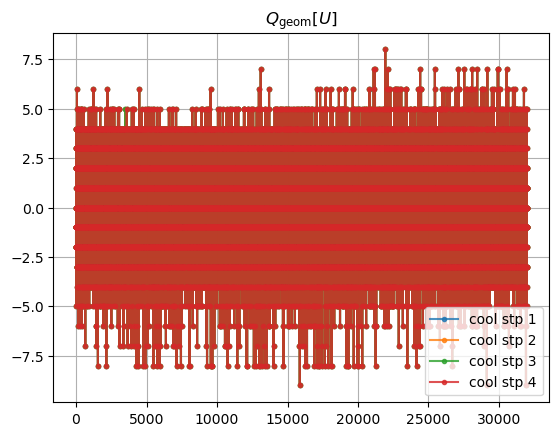

(-5.0, 5.0)

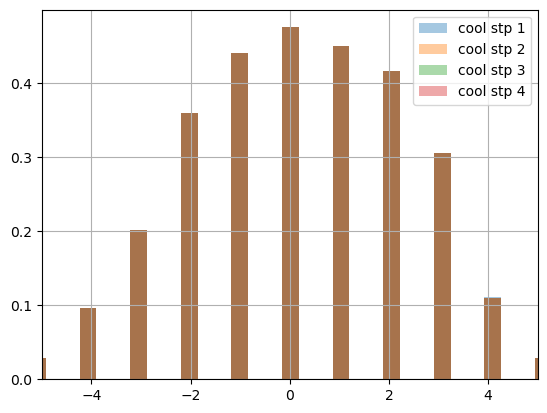

In [30]:
cool_stp = 1    # translates to meas_every_cool... * cool_stp cooling steps
for cool_stp in range(1, 5):
    plt.plot(topo_sorted[cool_stp::skip_topo,2][:40000], alpha=0.8, marker="o", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{geom}[U]$")
plt.show()

for cool_stp in range(1,5):
    plt.hist(topo_sorted[cool_stp::skip_topo,2][:40000], alpha=0.4, bins=50, label=f"cool stp {cool_stp}", density=True)
plt.grid()
plt.legend()
plt.xlim(-5,5)

In [31]:
c_step = 4
obs = topo_data[c_step::skip_topo,2]

avg_obs = np.sum(np.exp(log_w_norm)*obs)
print(avg_obs)

print("Thesis result for b=0.6, L=72, N=21:\t0.002(3)")
print("This is perhaps skewed by the fact that we are in the end trapped in one topological sector...!")

0.2690806703452443
Thesis result for b=0.6, L=72, N=21:	0.002(3)
This is perhaps skewed by the fact that we are in the end trapped in one topological sector...!


# Look at $\xi_L$

And what about the correlation length? 

$$
\xi_L^2 = \frac{1}{4\sin^2(k/2)} \left[ \frac{\tilde{G}_L(0)}{\tilde{G}_L(k)} - 1\right] , \ \ k= 2\pi/L
$$

Some of the G_L are negative? Should that be allowed?

In [32]:
k = 2*np.pi / L

In [33]:
obs_0 = gen_data[:,2]
obs_k = gen_data[:,3]

avg_obs_0 = np.sum(np.exp(log_w_norm)*obs_0)
avg_obs_k = np.sum(np.exp(log_w_norm)*obs_k)

xi_L2 = 1 / (4 * np.sin(k/2)**2) * (avg_obs_0/avg_obs_k - 1.)
print(f"xi_L={np.sqrt(xi_L2)}")

print("Thesis result for b=0.6, L=72, N=21:\t2.895(7)")

xi_L=3.1232329465153006
Thesis result for b=0.6, L=72, N=21:	2.895(7)


can we also shift by $\Delta\beta=0.1$?

And how do we get errors? From the statistical uncertainty of the weights if they are sampled from a Beta-distribution? Or from independent runs?

------

## below is old

In [51]:
#plt.hist(gen_data[:, 1], bins=55)

In [94]:
log_E = np.log(gen_data[-n_meas:, 1]) + pf

In [95]:
i=1
log_E[:i]+log_w[:i]

array([-5.74374009])

In [54]:
# average energy density:
obs = []
for i in range(0,len(energies)):
    obs.append(logsumexp(+log_E[:i+1]+log_w[:i+1]))     #-energies[:i]
obs = np.array(obs)
obs -= log_Z_norm
obs.shape
# log_Z_tot = logsumexp(-energies+log_w)

(1001,)

In [55]:
len(obs)

1001

In [56]:
obs[-1] # E / NV

0.4482074474958999

In [61]:
# average energy density:
obs = np.sum(gen_data[:, 1] * h_list)
obs * 2 # I think we need the factor 2? since its S/bNV and the code prints S/2bNV?

1.485808703360462

In [62]:
len(gen_data[:, 1]) 

1001

(array([59., 43., 58., 55., 63., 56., 53., 40., 42., 33., 25., 29., 35.,
        41., 31., 22., 28., 23., 19., 25., 22., 19., 15., 22., 21., 12.,
        11., 14.,  9.,  6.,  9.,  6.,  9.,  7.,  4.,  5.,  6.,  0.,  2.,
         2.,  3.,  2.,  3.,  3.,  1.,  0.,  1.,  2.,  3.,  0.,  0.,  0.,
         1.,  0.,  1.]),
 array([0.85545827, 0.85564762, 0.85583696, 0.85602631, 0.85621566,
        0.85640501, 0.85659435, 0.8567837 , 0.85697305, 0.8571624 ,
        0.85735174, 0.85754109, 0.85773044, 0.85791979, 0.85810913,
        0.85829848, 0.85848783, 0.85867718, 0.85886652, 0.85905587,
        0.85924522, 0.85943457, 0.85962391, 0.85981326, 0.86000261,
        0.86019196, 0.86038131, 0.86057065, 0.86076   , 0.86094935,
        0.8611387 , 0.86132804, 0.86151739, 0.86170674, 0.86189609,
        0.86208543, 0.86227478, 0.86246413, 0.86265348, 0.86284282,
        0.86303217, 0.86322152, 0.86341087, 0.86360021, 0.86378956,
        0.86397891, 0.86416826, 0.8643576 , 0.86454695, 0.8647363 ,
   

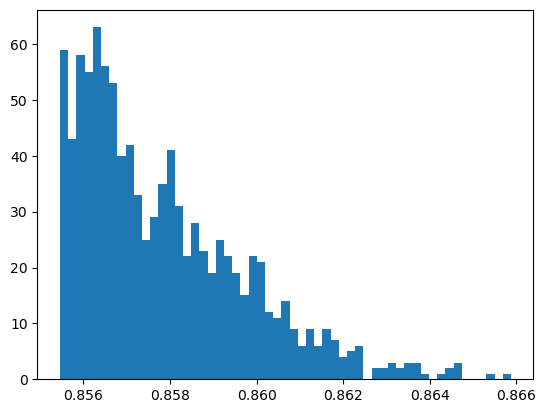

In [63]:
plt.hist(gen_data[-n_meas:, 1], bins=55)